In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import pdist, squareform
import sys
import importlib

# python source path
sys.path.append('../Src/')

# custom python 
import zscore_anomaly
import utils
import plot

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Scipy": scipy.__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int64 = pd.ArrowDtype(pa.int64())
arrow_bool = pd.ArrowDtype(pa.bool8())

  Library Version
0  Python  3.13.9
1  Pandas   2.3.3
2   NumPy   2.3.4
3   Scipy  1.16.3


In [2]:
# Read Arrow IPC file
with open('../Data/crime_data.arrow', 'rb') as f:
    reader = ipc.open_file(f)
    table = reader.read_all()
    
# Convert back to pandas (Arrow‑backed)
df = table.to_pandas(types_mapper=pd.ArrowDtype)
# Display
df.head()

,date,description,location_description,arrest,domestic,beat,district,ward,community_code,year,zip_code,zip_code_area,neighborhood,neighborhood_area,community_name,community_area,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,sector
0,2001-12-30 02:30:00,AUTOMOBILE,STREET,0,0,334,003,07,43,2001,60649,80526075.8505,South Shore,81812716.3904,South Shore,81812716.3958,December,Sunday,Q4,2001-Q4,Late Night,Motor Vehicle Theft,1,Grand Crossing,1
1,2001-12-24 12:30:00,FRAUD OR CONFIDENCE GAME,APARTMENT,0,0,2313,019,46,03,2001,60640,77305245.6358,Uptown,65095642.836,Uptown,65095642.7289,December,Monday,Q4,2001-Q4,Afternoon,Fraud,0,Town Hall,3
2,2001-12-31 23:00:00,FINANCIAL ID THEFT:$300 &UNDER,APARTMENT,0,0,1531,015,37,25,2001,60651,99039621.5713,Austin,170037750.826,Austin,199254203.427,December,Monday,Q4,2001-Q4,Night,Larceny – Theft,1,Austin,4
3,2001-12-23 22:30:00,AUTOMOBILE,STREET,0,0,1022,010,12,30,2001,60623,155285530.844,Little Village,127998297.819,South Lawndale,127998297.867,December,Sunday,Q4,2001-Q4,Night,Motor Vehicle Theft,1,Ogden,4
4,2001-12-31 20:00:00,PREDATORY,APARTMENT,0,0,1723,017,33,14,2001,60625,105830918.044,Albany Park,53542230.819,Albany Park,53542230.8191,December,Monday,Q4,2001-Q4,Night,Criminal Sexual Assault,1,Albany Park,5


In [3]:
# NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,469,872) ---
                       Count Percentage
neighborhood_area     116237    1.3724%
community_area        116237    1.3724%
zip_code_area         116181    1.3717%
ward                   84100    0.9929%
location_description   15338    0.1811%
community_code          9744    0.1150%
zip_code                9744    0.1150%
neighborhood            9744    0.1150%
community_name          9744    0.1150%
district                 139    0.0016%
district_location        139    0.0016%
sector                   139    0.0016%


#### Calculating the Z-score highlights specialized anomalies
- A Z-score of 3.0
    - The value is higher than about 99.87% of all values in a normal distribution 
    - It’s an extreme outlier
- A Z‑score of 2 means:
    - The value is higher than about 97.7% of all values in a normal distribution
    - That year’s count is significantly higher than the historical average
- A Z-score of -1:
    - The value is lower than about 84% of all values
    - It’s a mild decrease, not extreme

##### User Function(s)

In [18]:
def heat_map(data: pd.DataFrame, typ: str='Indexed', figsize: tuple=(16, 6)) -> None:
    # Create the Heatmap
    plt.figure(figsize=figsize)
    sns. heatmap(
        data,
        cmap="RdBu_r",          # Red for high Z-scores, Blue for low
        center=0,               # White represents the mean
        annot=True,             # Change to False if you don't want to see the numbers
        fmt=".2f",              # format as integers
        annot_kws={"size": 8}, # change font size here
        linewidths=.5
    )
    plt.title(f"Z‑Score Heatmap ({typ} Crimes)", fontsize=16)
    plt.xlabel("Year", fontsize=10)
    plt.ylabel("Crime Type", fontsize=12)
    plt.yticks(fontsize=10, rotation=0, ha='right')
    plt.xticks(fontsize=10, rotation=45, ha='right')
    plt.show()

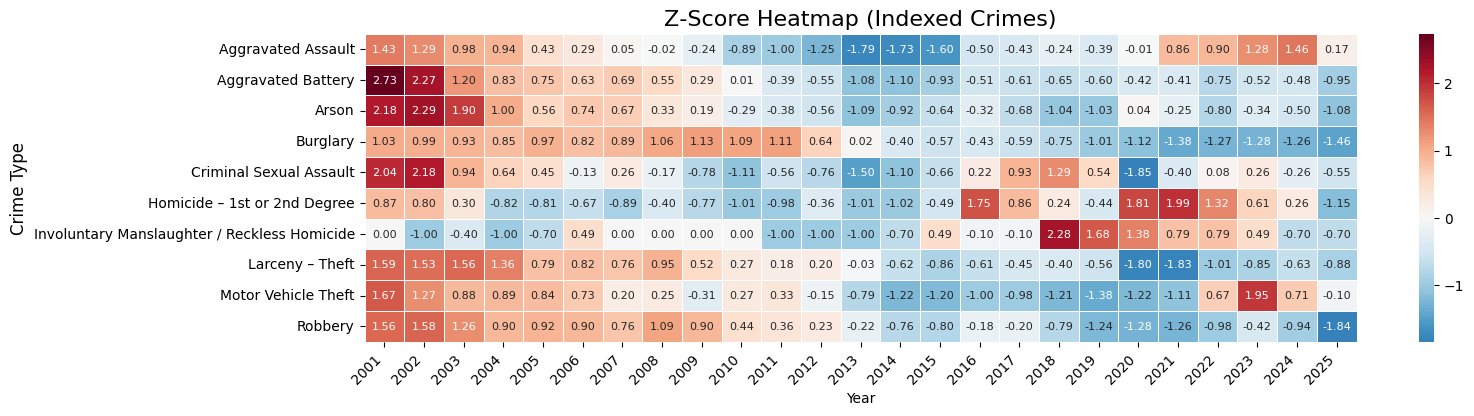

In [19]:
# Calculate z-scores Indexed Crime
df.fbi_index_code = df.fbi_index_code.astype('bool')
mask = df.fbi_index_code == True
z_df_i = zscore_anomaly.zscore_anomaly(data=df[mask], time_col='year', category_col='fbi_code_desc')
# plot
heat_map(z_df_i, 'Indexed', (16,4))

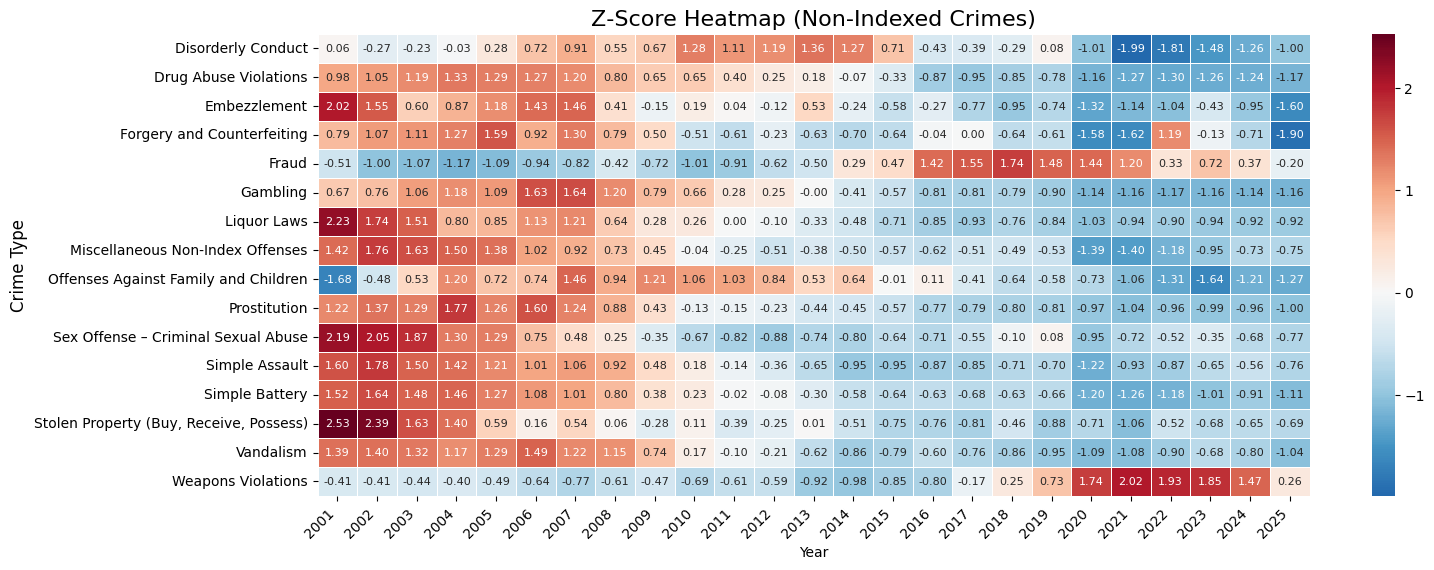

In [20]:
# Calculate z-scores Non-Indexed Crime
mask = df.fbi_index_code == False
z_df_n = zscore_anomaly.zscore_anomaly(data=df[mask],time_col='year', category_col='fbi_code_desc')
heat_map(z_df_n, 'Non-Indexed')

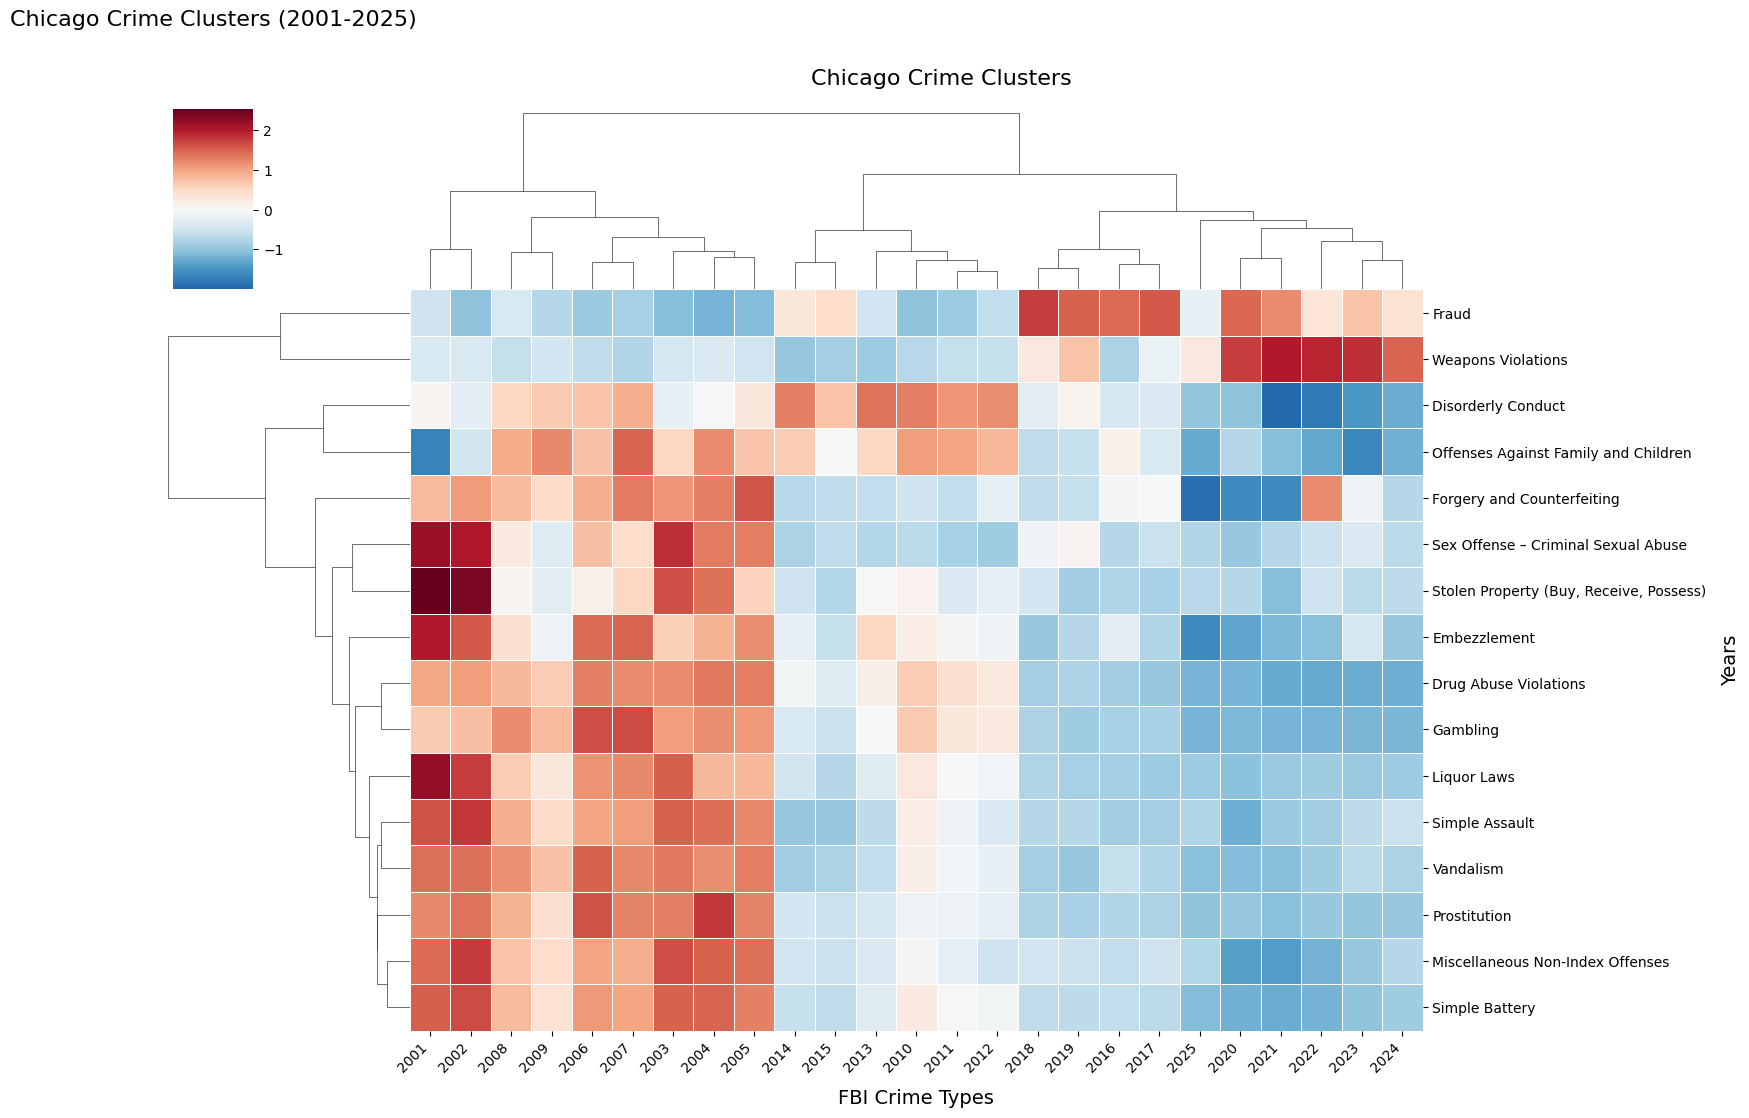

In [22]:
# Z score
z_df = zscore_anomaly.zscore_anomaly(data=df[mask], time_col='year', category_col='fbi_code_desc')

# Create the clustermap
g = sns.clustermap(
    z_df, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

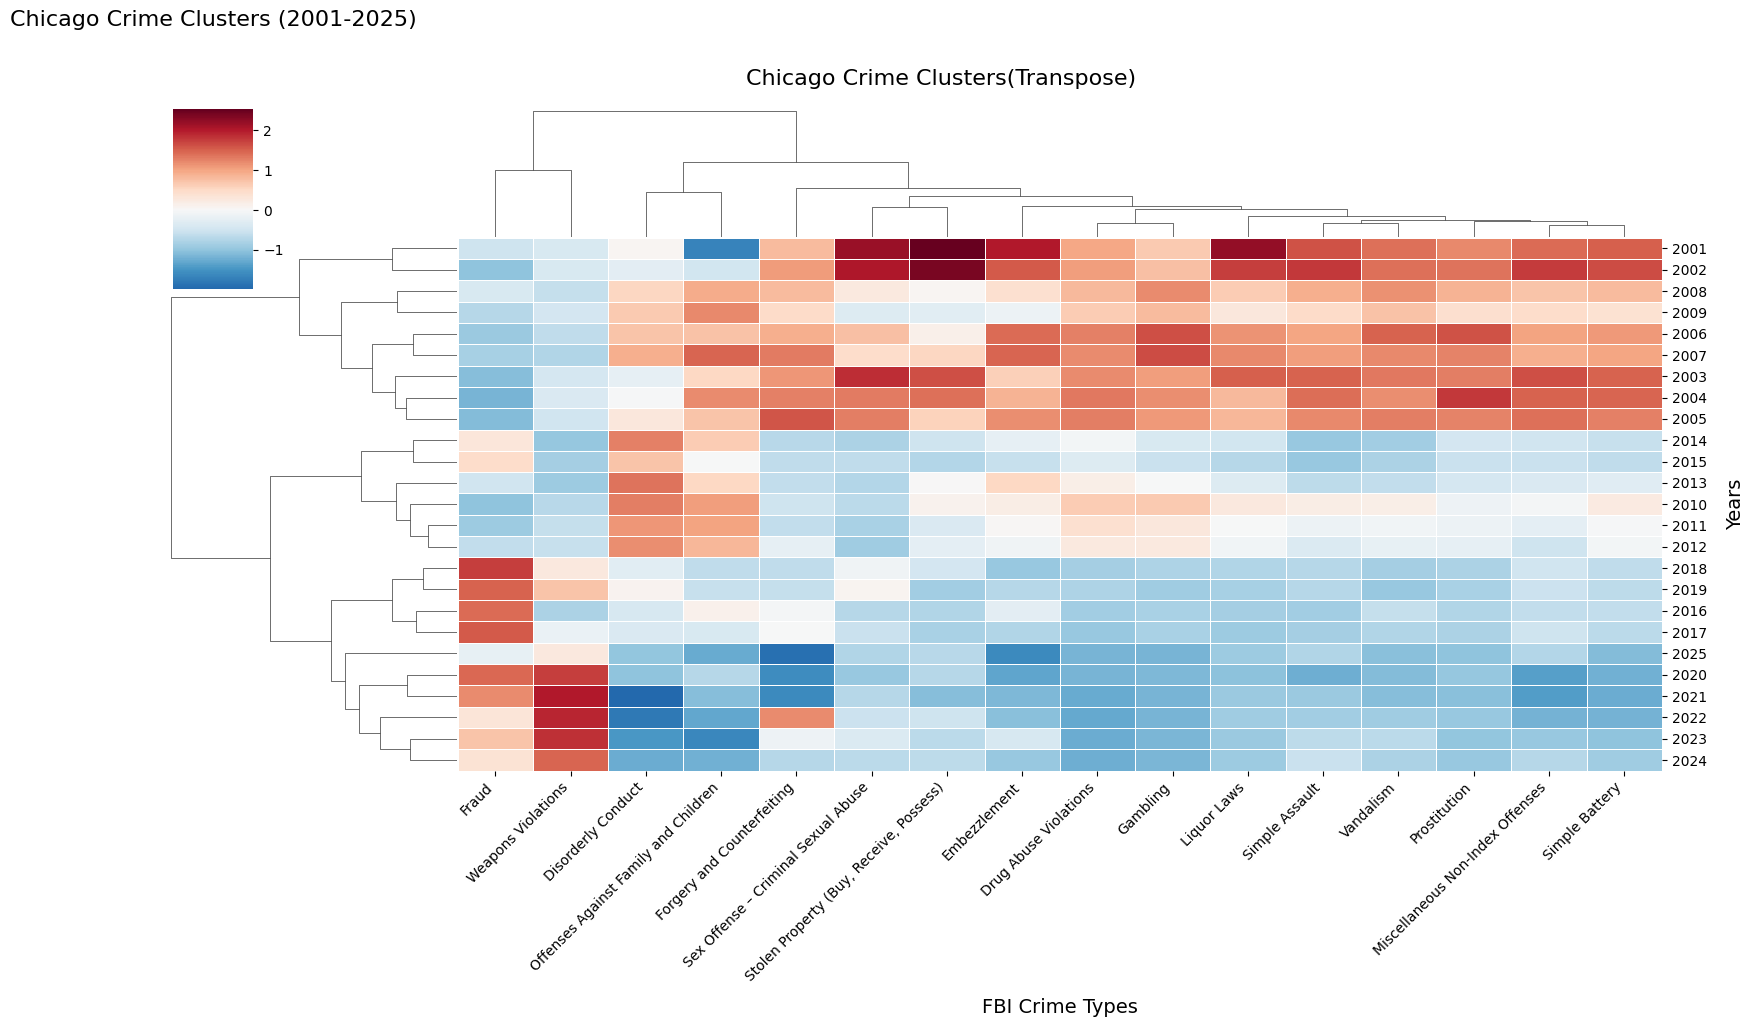

In [28]:
# Create the rotated clustermap
g_t = sns.clustermap(
    z_df.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g_t.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
# Labels
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters(Transpose)", fontsize=16, y=1.02)
g_t.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g_t.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=14)
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_rotate_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

**Note:**
1. The Color Intensity (The Values)
* Since you are using Z-scores, look at the color first:
  - Deep Red: The crime count for that specific year was significantly above its historical average.
    - Deep Blue: The crime count for that specific year was significantly below its historical average.
    - White/Light Colors: The crime count was "normal" or very close to the 25-year mean.

2. The Dendrogram (The "Tree" Structure)
* The branches on the top (or side) tell you how similar items are.
* Close Neighbors: If two crime types are connected by a short "U-shaped" branch, they have very similar patterns over the 25-year period.
* Branch Length: The longer the vertical lines of the branch before they join, the less similar those two groups are.

3. Reading the "Clusters" (The Groups)
*  The "Legacy" Cluster: Crimes that were rampant in the early 2000s but have since crashed (like Drug Abuse Violations or Prostitution). These will be Red on the top-left and deep Blue on the bottom-right.
* The "Resilient" Cluster: Crimes that have stayed consistently high or "Red" for almost the entire 25 years. These are the persistent issues Chicago faces.
* The "Modern Surge" Cluster: Crimes that were blue for years but have recently turned bright Red (like Motor Vehicle Theft and Weapons Violations).

4. Reading the X and Y Axis Together
* To find a specific "Anomaly," look for a single "pop" of color that breaks a trend.
* Vertical Red Streaks: If you see a vertical column of red across many crimes for a single year (like 2020), it suggests an External Event (like the Pandemic or civil unrest) affected almost everything at once.
* Horizontal Red Streaks: If one crime type is red across many years, it shows a long-term sustained increase for that specific category.

5. Why the "Rotation" Helps
* By rotating the plot, you can now scan horizontally to see which crimes behave similarly in the same year, and scan vertically to see how a single crime's "fortune" has changed from 2001 to 2025.

**Tip: The "Pivot Point"**
* Look for where the colors flip from Blue to Red. In Chicago's data, there is often a "pivot" around 2016 and 2020. These are the years where the "old" patterns of crime significantly shifted into the "modern" patterns we see today.

### Clustering

In [8]:
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)

# Raw linkage matrix, and this matrix tells the entire story of your dendrogram’s structure
#  cluster A, cluster B, merge height, cluster size
Z = g.dendrogram_col.linkage

# print
print (Z)

[[10.     11.      1.2293  2.    ]
 [ 5.      6.      1.4137  2.    ]
 [17.     18.      1.5652  2.    ]
 [15.     16.      1.5823  2.    ]
 [ 3.      4.      1.5832  2.    ]
 [13.     14.      1.8074  2.    ]
 [ 9.     25.      1.81    3.    ]
 [ 7.      8.      1.8447  2.    ]
 [ 0.      1.      1.9932  2.    ]
 [19.     20.      2.225   2.    ]
 [22.     23.      2.2442  2.    ]
 [26.     29.      2.3485  4.    ]
 [12.     30.      2.4461  3.    ]
 [21.     35.      2.6694  3.    ]
 [ 2.     36.      3.019   5.    ]
 [31.     32.      3.2429  5.    ]
 [27.     28.      3.3058  4.    ]
 [24.     38.      4.2575  4.    ]
 [37.     40.      4.3219  8.    ]
 [34.     42.      4.457   6.    ]
 [41.     44.      4.7213 10.    ]
 [33.     39.      4.8618  7.    ]
 [43.     45.      6.5571 18.    ]
 [46.     47.      8.7263 25.    ]]


The output above is a raw linkage matrix from the `g.dendrogram_col.linkage` object, and this matrix tells the entire story of our dendrogram’s structure. The significant jump from 5.70 to 8.05 indicates we have located the "elbow" of the dendrogram, where the mathematical cohesion of the groups breaks down, and at this stage, we are no longer joining "similar" crime types but rather forcing distinct behavioral patterns into a single, over-generalized category. 

In [9]:
# Calculate the inconsistent statistics
from scipy.cluster.hierarchy import inconsistent

# Inconsistency coefficient column
I = inconsistent(Z, 2)   # depth=2 is the standard choice

# print
print(I)

[[1.2293 0.     1.     0.    ]
 [1.4137 0.     1.     0.    ]
 [1.5652 0.     1.     0.    ]
 [1.5823 0.     1.     0.    ]
 [1.5832 0.     1.     0.    ]
 [1.8074 0.     1.     0.    ]
 [1.5196 0.4106 2.     0.7071]
 [1.8447 0.     1.     0.    ]
 [1.9932 0.     1.     0.    ]
 [2.225  0.     1.     0.    ]
 [2.2442 0.     1.     0.    ]
 [1.7818 0.498  3.     1.1379]
 [2.1268 0.4516 2.     0.7071]
 [2.4568 0.3007 2.     0.7071]
 [2.6837 0.4741 2.     0.7071]
 [2.2992 0.8175 3.     1.1544]
 [2.1511 1.     3.     1.1547]
 [3.4635 1.1229 2.     0.7071]
 [3.337  0.9414 3.     1.0462]
 [3.6465 1.2351 3.     0.6562]
 [4.1614 0.7527 3.     0.744 ]
 [3.2913 1.4535 3.     1.0804]
 [5.2001 1.1921 3.     1.1384]
 [6.7151 1.9371 3.     1.0383]]


- Each row of the inconsistency matrix has four values:
    - Mean of the merge heights in the local neighborhood
    - Standard deviation of those heights
    - Number of links used in the local neighborhood
    - Inconsistency coefficient : 
$
\text{inconsistency}_i = \frac{Z_{[i,2]} - \text{Local mean}}{\text{local Std}}
$


**The fourth column is the one that matters for evaluating cluster stability.**

- 0.0 $\rightarrow$ the merge height is identical to the local average $\rightarrow$ extremely natural merge
- 0.6 – 0.8 $\rightarrow$ mild deviation $\rightarrow$ still natural, but slightly broader merges
- 0.9 – 1.2 $\rightarrow$ noticeable deviation $\rightarrow$ the algorithm is merging groups that are less similar
- $\gt$ 2.0 (not present in your data) $\rightarrow$ strongly unnatural merges $\rightarrow$ forced merges across major cluster boundaries

Our matrix never exceeds 1.15, indicating that the dataset has a smooth hierarchical structure with no abrupt discontinuities.

In [10]:
# Inspect inconsistency
heights = Z[:, 2] 
incons = I[:, 3]

print(heights) 
print(incons)

[1.2293 1.4137 1.5652 1.5823 1.5832 1.8074 1.81   1.8447 1.9932 2.225  2.2442 2.3485 2.4461 2.6694
 3.019  3.2429 3.3058 4.2575 4.3219 4.457  4.7213 4.8618 6.5571 8.7263]
[0.     0.     0.     0.     0.     0.     0.7071 0.     0.     0.     0.     1.1379 0.7071 0.7071
 0.7071 1.1544 1.1547 0.7071 1.0462 0.6562 0.744  1.0804 1.1384 1.0383]


In [11]:
# Find merges with higher inconsistency,
idx_high = np.where(incons > 1.0)[0]
critical_heights = heights[idx_high]
# Critical_heights are where merges start to be “stretched”.
critical_heights

array([2.3485, 3.2429, 3.3058, 4.3219, 4.8618, 6.5571, 8.7263])

The first true anomaly is at height 2.3485, but the real structural break begins at height $\approx$ 3.24 with an inconsistency value of 1.1544 (incons).
Let's cut at 3.24, since anything below is stable.

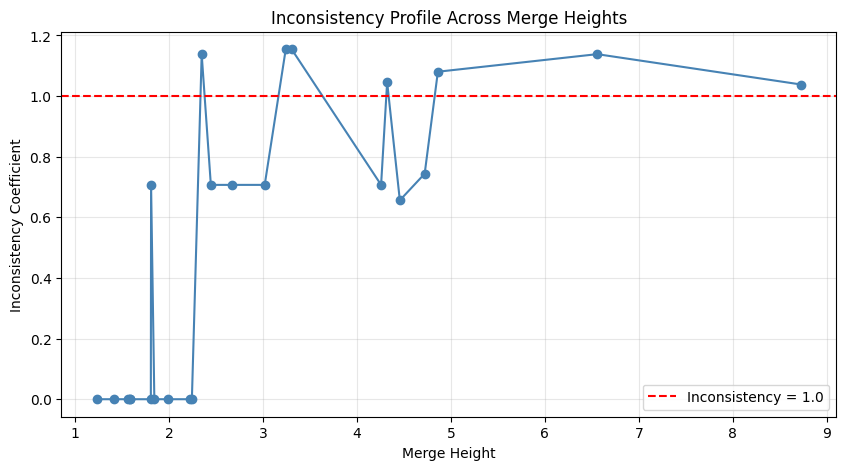

In [12]:
plot.plot_cuts(heights, incons)

In [13]:
# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
T_values = [3.2, 4.3, 4.8]

for T in T_values:
    # Get the linkage and clusters
    linkage = g.dendrogram_col.linkage 
    # clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
    clusters = fcluster(linkage, t=T, criterion='distance')
    
    
    # Create the mapping using .columns instead of .index
    # This matches the names on the X-axis of your rotated plot
    crime_groups = pd.DataFrame({
        'fbi_code_desc': z_score.columns, 
        'cluster_id': clusters
    }).sort_values('cluster_id')
    
    # Display the members
    for cluster_num in range(1, (len(np.unique(clusters))) + 1):
        members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
        print(f"--- Cluster {cluster_num} & {T} Distance Calculation value ---")
        print("\n".join([f"  • {m}" for m in members]))
        print("-" * 30)
    print("\n")

--- Cluster 1 & 3.2 Distance Calculation value ---
  • 2001
  • 2002
------------------------------
--- Cluster 2 & 3.2 Distance Calculation value ---
  • 2003
  • 2004
  • 2005
  • 2006
  • 2007
------------------------------
--- Cluster 3 & 3.2 Distance Calculation value ---
  • 2015
  • 2014
  • 2013
------------------------------
--- Cluster 4 & 3.2 Distance Calculation value ---
  • 2011
  • 2012
  • 2010
------------------------------
--- Cluster 5 & 3.2 Distance Calculation value ---
  • 2009
  • 2008
------------------------------
--- Cluster 6 & 3.2 Distance Calculation value ---
  • 2018
  • 2019
------------------------------
--- Cluster 7 & 3.2 Distance Calculation value ---
  • 2016
  • 2017
------------------------------
--- Cluster 8 & 3.2 Distance Calculation value ---
  • 2020
  • 2021
------------------------------
--- Cluster 9 & 3.2 Distance Calculation value ---
  • 2024
  • 2022
  • 2023
------------------------------
--- Cluster 10 & 3.2 Distance Calculation valu

In [14]:
# cuts
cuts = T_values.copy()
# generate the cluster labels at each cut height
labels = {h: fcluster(Z, t=h, criterion='distance') for h in cuts}

# clusters at each height
print("Clusters @ each hight:" ,{k: len(set(v)) for k, v in labels.items()})

def similarity(a, b):
    return np.mean(a == b)

# score
similarity(labels[3.2], labels[4.3]), similarity(labels[4.3], labels[4.8])

Clusters @ each hight: {3.2: 10, 4.3: 7, 4.8: 4}


(np.float64(0.52), np.float64(0.4))

In [15]:
# generate the cluster labels at each cut height
labels = {h: fcluster(Z, t=h, criterion='distance') for h in cuts}
labels

{3.2: array([ 1,  1,  2,  2,  2,  2,  2,  5,  5,  4,  4,  4,  3,  3,  3,  7,  7,  6,  6,  8,  8,  9,  9,
         9, 10], dtype=int32),
 4.3: array([1, 1, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 3, 3, 3, 5, 5, 5, 5, 6, 6, 7, 7, 7, 7], dtype=int32),
 4.8: array([1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)}

In [16]:
from sklearn.metrics import silhouette_score

# Silhouette score (cluster quality)
scores = {h: silhouette_score(z_score.T, labels[h]) for h in labels}
scores

{3.2: 0.360935572688038, 4.3: 0.3529353449340224, 4.8: 0.3640623559675599}

**Silhouette score for hierarchical clustering on standardized temporal profiles:**
- 0.20–0.30 $\rightarrow$ weak but usable
- 0.30–0.40 $\rightarrow$ moderate, interpretable structure
- 0.40+ $\rightarrow$ strong, rarely seen in noisy real‑world time series

In [17]:
# Create a list to store dataframes with their threshold ID
centroid_list = []

for h, lab in labels.items():
    # Ensure we are working with Crime as Rows, Years as Columns
    # If your z_score is already (Crimes x Years), don't use .T
    df_tmp = z_score.T.copy() 
    df_tmp['cluster'] = lab
    
    # Calculate means and add the threshold 'h' as a column
    mean_df = df_tmp.groupby('cluster').mean().assign(threshold=h)
    centroid_list.append(mean_df)

# Concatenate into one master DataFrame
df_centroids = pd.concat(centroid_list).reset_index()

# View the result
mask = df_centroids.threshold == 3.2
df_centroids.loc[mask]

# # Inspect cluster centroids
# centroids = {}
# for h, lab in labels.items():
#     df_tmp = pd.DataFrame(z_score.T)
#     df_tmp['cluster'] = lab
#     centroids[h] = df_tmp.groupby('cluster').mean()
# centroids

fbi_code_desc,cluster,Aggravated Assault,Aggravated Battery,Arson,Burglary,Criminal Sexual Assault,Disorderly Conduct,Drug Abuse Violations,Embezzlement,Forgery and Counterfeiting,Fraud,Gambling,Homicide – 1st or 2nd Degree,Involuntary Manslaughter / Reckless Homicide,Larceny – Theft,Liquor Laws,Miscellaneous Non-Index Offenses,Motor Vehicle Theft,Offenses Against Family and Children,Prostitution,Robbery,Sex Offense – Criminal Sexual Abuse,Simple Assault,Simple Battery,"Stolen Property (Buy, Receive, Possess)",Vandalism,Weapons Violations,threshold
0,1,1.359291,2.500375,2.235794,1.009848,2.107538,-0.107229,1.015986,1.786275,0.927366,-0.759123,0.712264,0.836539,-0.498457,1.557882,1.982069,1.587405,1.471205,-1.080569,1.293003,1.567501,2.118986,1.692350,1.582614,2.461500,1.393775,-0.407240,3.2
1,2,0.539074,0.820466,0.976270,0.892720,0.430997,0.332100,1.258533,1.108765,1.240896,-1.021649,1.320847,-0.574644,-0.321393,1.060087,1.100126,1.289650,0.708001,0.931540,1.433760,0.944965,1.138253,1.239701,1.261138,0.861951,1.298776,-0.548071,3.2
2,3,-1.707335,-1.039382,-0.883099,-0.315113,-1.086817,1.114520,-0.075572,-0.095697,-0.656203,0.087354,-0.327199,-0.842683,-0.401741,-0.504119,-0.506551,-0.484444,-1.070263,0.387976,-0.488907,-0.589755,-0.729524,-0.850602,-0.510084,-0.418935,-0.755431,-0.917307,3.2
3,4,-1.045769,-0.308205,-0.409493,0.944471,-0.809375,1.191511,0.432948,0.038361,-0.450489,-0.847868,0.399763,-0.781765,-0.664609,0.214160,0.056978,-0.267960,0.152259,0.975762,-0.170237,0.345332,-0.789753,-0.104582,0.045263,-0.176736,-0.046645,-0.631656,3.2
4,5,-0.133027,0.419258,0.256253,1.094073,-0.474369,0.607343,0.727854,0.131171,0.643591,-0.567993,0.999276,-0.585768,0.000000,0.734547,0.462720,0.588624,-0.031699,1.075262,0.655221,0.994944,-0.049268,0.700567,0.588120,-0.112726,0.943003,-0.538101,3.2
5,6,-0.314713,-0.627655,-1.035631,-0.880279,0.915671,-0.104823,-0.817020,-0.843330,-0.624673,1.609908,-0.845938,-0.101071,1.978947,-0.480275,-0.800314,-0.507224,-1.295472,-0.607944,-0.805990,-1.012752,-0.014134,-0.708695,-0.645074,-0.668053,-0.904445,0.491091,3.2
6,7,-0.465150,-0.561575,-0.502191,-0.511388,0.575946,-0.412305,-0.908843,-0.518496,-0.020388,1.486610,-0.810186,1.305343,-0.104155,-0.532078,-0.889752,-0.566572,-0.991674,-0.146375,-0.780122,-0.188029,-0.628472,-0.856662,-0.651447,-0.787423,-0.681566,-0.486504,3.2
7,8,0.428099,-0.417295,-0.102744,-1.253043,-1.122677,-1.498839,-1.213819,-1.230037,-1.598141,1.317848,-1.149832,1.897309,1.086189,-1.811486,-0.989006,-1.392851,-1.163842,-0.895389,-1.001339,-1.267058,-0.833252,-1.077417,-1.228719,-0.886032,-1.086093,1.880212,3.2
8,9,1.213318,-0.579431,-0.542642,-1.269496,0.026725,-1.515681,-1.267313,-0.807237,0.119510,0.471917,-1.157446,0.730594,0.193431,-0.830075,-0.920291,-0.953507,1.111467,-1.388282,-0.970778,-0.779359,-0.518052,-0.690183,-1.032160,-0.616154,-0.793747,1.748936,3.2
9,10,0.174989,-0.947496,-1.078609,-1.461606,-0.550807,-0.999842,-1.171168,-1.601275,-1.898447,-0.200463,-1.160757,-1.149923,-0.699327,-0.877510,-0.922473,-0.749281,-0.097432,-1.274041,-1.000578,-1.842692,-0.767000,-0.762690,-1.105734,-0.688813,-1.035758,0.261523,3.2


#### Tranpost Z-Scores

In [18]:
# Raw Tranpost linkage matrix, and this matrix tells the entire story of your dendrogram’s structure
Z_t = g_t.dendrogram_col.linkage

# Inconsistency coefficient column
I_t = inconsistent(Z_t, 2)   # depth=2 is the standard choice

In [19]:
# Inspect inconsistency
heights_t = Z_t[:, 2] 
incons_t = I_t[:, 3]

print(heights_t) 
print(incons_t)

[0.8366 1.0288 1.0372 1.1784 1.209  1.3467 1.5009 1.6691 1.6799 1.9824 2.0901 2.1495 2.2095 2.2471
 3.0022 3.1625 3.5324 3.7346 3.9058 4.3386 4.734  4.777  5.0385 5.705  8.0516]
[0.     0.     0.     0.7071 0.7288 0.     0.7071 0.7071 0.7071 0.7071 0.7071 0.7071 0.7071 0.6345
 1.1484 0.     0.7071 0.     0.     0.     0.9238 0.7071 0.7322 0.8114 1.1069]


In [20]:
# Find merges with higher inconsistency,
idx_high_t = np.where(incons_t > 1.0)[0]
critical_heights_t = heights_t[idx_high_t]
# Critical_heights are where merges start to be “stretched”.
critical_heights_t

array([3.0022, 8.0516])

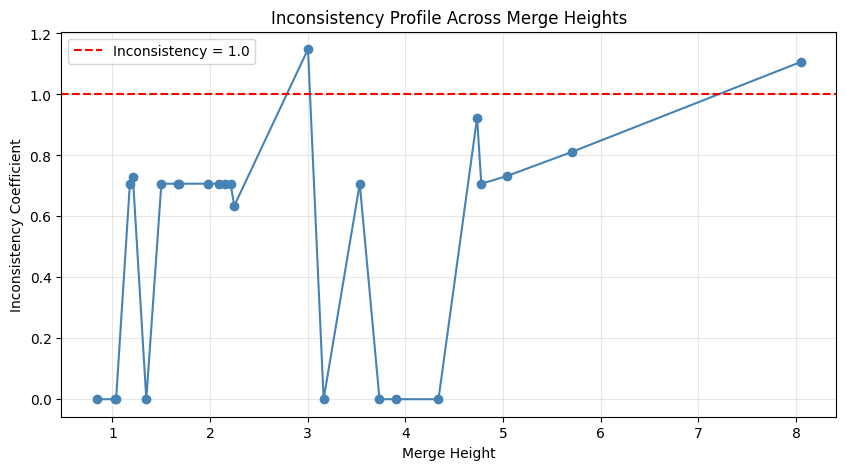

In [21]:
plot.plot_cuts(heights_t, incons_t)

In [22]:
# Test these
cuts_t = [2.0, 2.5, 3.3]
# generate the cluster labels at each cut height
labels_t = {h: fcluster(Z_t, t=h, criterion='distance') for h in cuts_t}

for h in cuts_t:
    n_clus = len(set(fcluster(Z_t, t=h, criterion='distance')))
    print(f"h={h}: {n_clus} clusters")

# score
similarity(labels_t[2.0], labels_t[2.5]), similarity(labels_t[2.5], labels_t[3.3])

h=2.0: 16 clusters
h=2.5: 12 clusters
h=3.3: 10 clusters


(np.float64(0.3076923076923077), np.float64(0.19230769230769232))

In [23]:
# Silhouette score (cluster quality)
scores = {h: silhouette_score(z_score, labels_t[h]) for h in labels_t}
scores

{2.0: 0.14697931690893415, 2.5: 0.207598609119583, 3.3: 0.23307071478888106}

In [24]:
# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
for h in cuts_t:
    # Get the linkage and clusters
    linkage = g_t.dendrogram_col.linkage 
    # clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
    clusters_t = fcluster(linkage, t=h, criterion='distance')
    
    # Create the mapping using .columns instead of .index
    # This matches the names on the X-axis of your rotated plot
    crime_groups_t = pd.DataFrame({
        'fbi_code_desc': z_score.T.columns, 
        'cluster_id': clusters_t
    }).sort_values('cluster_id')
    
    # Display the members
    for cluster_num in range(1, (len(np.unique(clusters_t))) + 1):
        members = crime_groups_t[crime_groups_t['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
        print(f"--- Cluster {cluster_num} & {h} Distance Calculation value ---")
        print("\n".join([f"  • {m}" for m in members]))
        print("-" * 30)
    print("\n")

--- Cluster 1 & 2.0 Distance Calculation value ---
  • Fraud
------------------------------
--- Cluster 2 & 2.0 Distance Calculation value ---
  • Involuntary Manslaughter / Reckless Homicide
------------------------------
--- Cluster 3 & 2.0 Distance Calculation value ---
  • Homicide – 1st or 2nd Degree
------------------------------
--- Cluster 4 & 2.0 Distance Calculation value ---
  • Weapons Violations
------------------------------
--- Cluster 5 & 2.0 Distance Calculation value ---
  • Disorderly Conduct
------------------------------
--- Cluster 6 & 2.0 Distance Calculation value ---
  • Offenses Against Family and Children
------------------------------
--- Cluster 7 & 2.0 Distance Calculation value ---
  • Arson
  • Aggravated Battery
------------------------------
--- Cluster 8 & 2.0 Distance Calculation value ---
  • Stolen Property (Buy, Receive, Possess)
------------------------------
--- Cluster 9 & 2.0 Distance Calculation value ---
  • Sex Offense – Criminal Sexual Abu

In [39]:
a = np.array([1,2, 3])
b = np.array([4, 5, 6])

In [41]:
a.dot(b.T), a*b.T

(np.int64(32), array([ 4, 10, 18]))